# 🔍 Model Explainability – Boston Housing

Este notebook tiene como objetivo entender cómo el modelo toma decisiones, qué variables influyen más en la predicción y analizar posibles sesgos asociados a variables socioeconómicas.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import sys
import os

sys.path.append(os.path.abspath(".."))

from src.data import load_data, split_data
from src.predict import load_model

from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.model_selection import train_test_split

sns.set(style="whitegrid")

In [2]:
df = load_data()
X, y = split_data(df)

model = load_model()

X.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33


In [3]:
rf_model = model.named_steps["model"]

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf_model.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance

,feature,importance
5,RM,0.492309
12,LSTAT,0.323469
7,DIS,0.056308
0,CRIM,0.038540
4,NOX,0.015979
10,PTRATIO,0.015956
9,TAX,0.015470
6,AGE,0.015199
11,B,0.012431
2,INDUS,0.007021


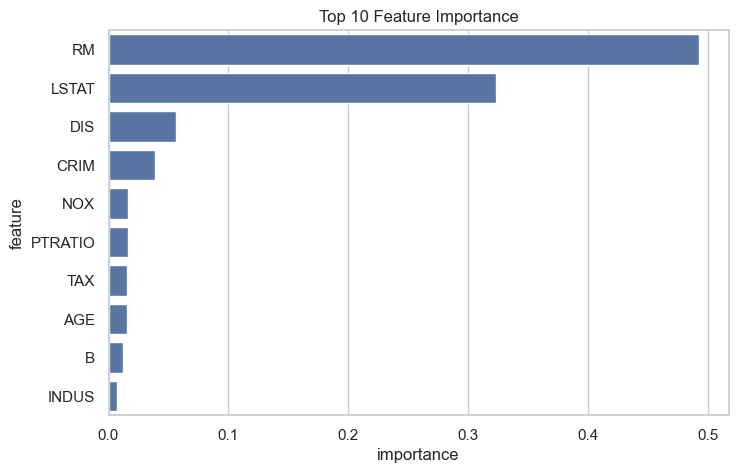

In [4]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=feature_importance.head(10),
    x="importance",
    y="feature"
)
plt.title("Top 10 Feature Importance")
plt.show()

In [5]:
_, X_test, _, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

perm = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="neg_mean_absolute_error"
)

perm_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": perm.importances_mean
}).sort_values(by="importance", ascending=False)

perm_importance

,feature,importance
12,LSTAT,2.502820
5,RM,2.118854
0,CRIM,0.421188
7,DIS,0.340875
4,NOX,0.261671
10,PTRATIO,0.182625
6,AGE,0.139250
9,TAX,0.090909
8,RAD,0.014891
2,INDUS,0.013219


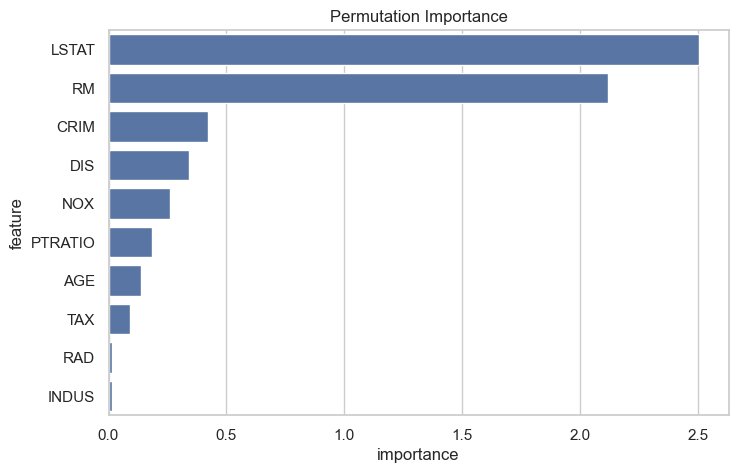

In [6]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=perm_importance.head(10),
    x="importance",
    y="feature"
)
plt.title("Permutation Importance")
plt.show()

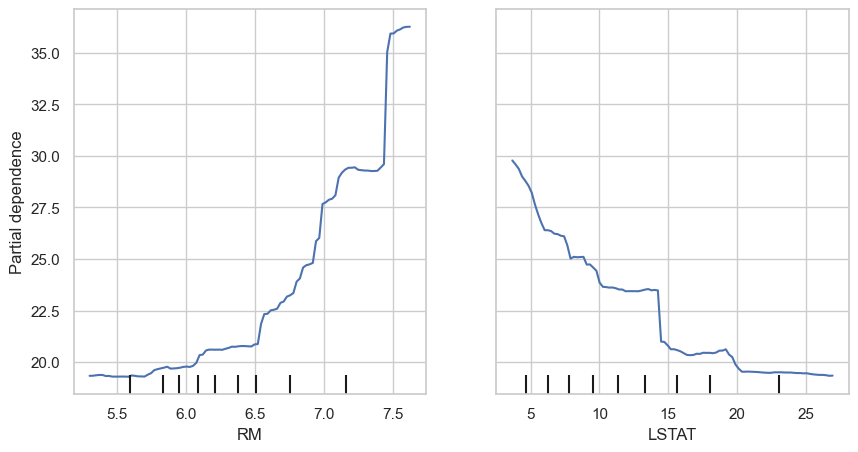

In [7]:
fig, ax = plt.subplots(figsize=(10,5))

PartialDependenceDisplay.from_estimator(
    model,
    X,
    features=["RM", "LSTAT"],
    ax=ax
)

plt.show()

In [8]:
df["prediction"] = model.predict(X)
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV,prediction
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0,28.5845
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6,22.0030
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7,34.0240
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4,33.9520
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2,35.5965


In [9]:
df["lstat_group"] = pd.qcut(
    df["LSTAT"],
    q=3,
    labels=["Low", "Medium", "High"]
)

df.groupby("lstat_group")[["MEDV", "prediction"]].mean()

C:\Users\quimb\AppData\Local\Temp\ipykernel_25276\1866665722.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("lstat_group")[["MEDV", "prediction"]].mean()


,MEDV,prediction
lstat_group,,
Low,30.976331,30.776118
Medium,21.733929,21.827393
High,14.883432,14.922231


In [10]:
df["error"] = abs(df["MEDV"] - df["prediction"])

df.groupby("lstat_group")["error"].mean()

C:\Users\quimb\AppData\Local\Temp\ipykernel_25276\2798011759.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("lstat_group")["error"].mean()


lstat_group
Low       1.202497
Medium    1.065839
High      1.116574
Name: error, dtype: float64

## 🧠 Conclusiones

- Variables como RM y LSTAT son las más influyentes en el modelo.
- Existe una relación no lineal entre estas variables y el precio.
- Se observa variación en el error del modelo según segmentos socioeconómicos.
- Esto sugiere la necesidad de monitorear fairness en producción.

## ⚠️ Consideraciones

El modelo utiliza variables socioeconómicas sensibles, por lo que puede reflejar sesgos históricos presentes en los datos.